# 4. 训练感知量化

## 4.1. 训练感知量化API说明

### (1) torch.ao中与训练感知量化相关的API结构

```python
from torch.ao.quantization import (
    # 配置类
    QConfig,
    QConfigMapping,
    # 观察器
    MinMaxObserver,
    MovingAverageMinMaxObserver,
    PerChannelMinMaxObserver,
    HistogramObserver,
    # 伪造量化
    FakeQuantize,
    # 准备和转换
    prepare_qat,
    convert,
    # 融合
    fuse_modules
)
```

### (2) 训练感知模型工作框架

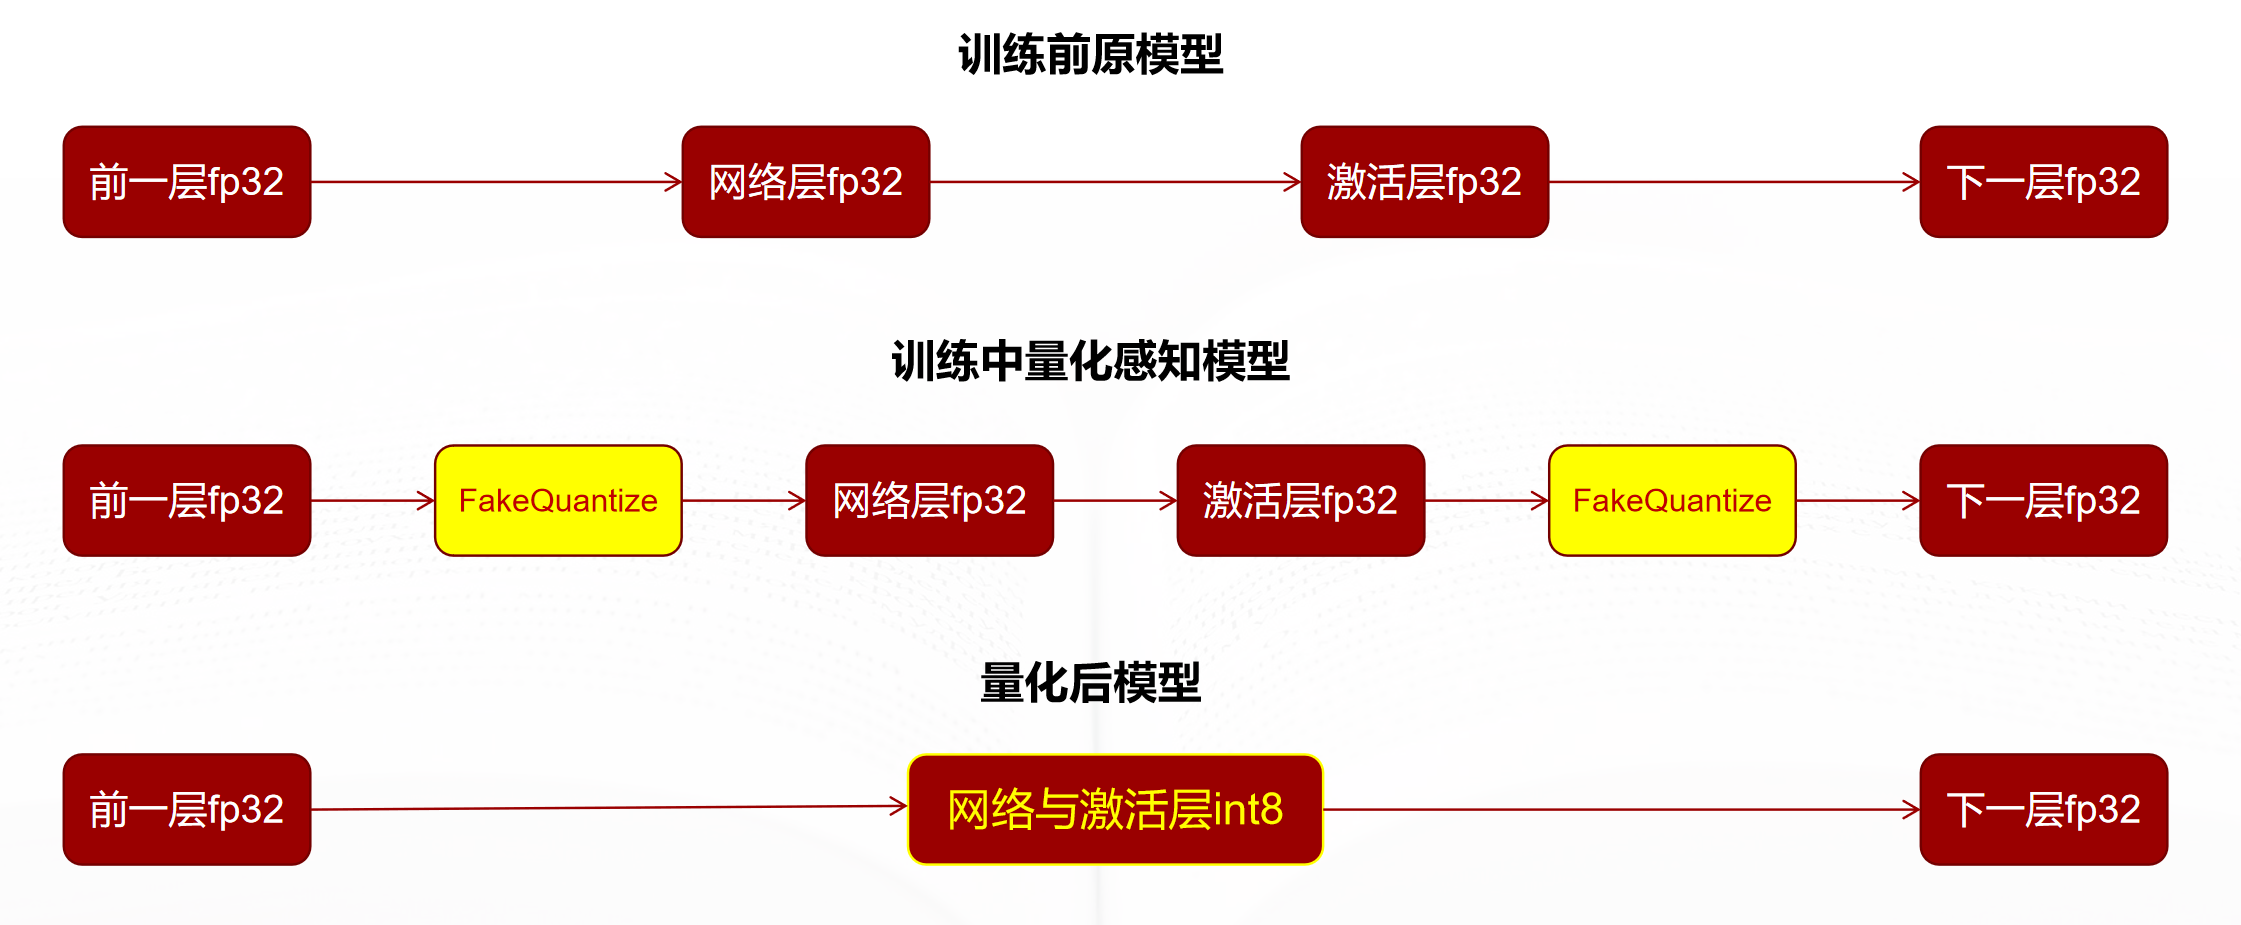

- 量化感知训练（QAT）在训练过程中模拟量化效果，因此相比其他量化方法能获得更高精度。我们可以针对静态、动态或仅权重量化执行QAT。训练期间，所有计算均采用浮点运算，通过fake_quant模块对数值进行裁剪和舍入来模拟INT8的量化效应。模型转换后，权重和激活值会被量化，并在可能的情况下将激活层融合到前一层中。该方法通常与CNN配合使用，相比静态量化能实现更高精度。
    - 注意：QAT中动态或仅权重量化已经被限制支持。

### (3) 训练感知量化的工作流程与相关API介绍

- (a) 定义神经网络模型
    - 在这个过程，可以使用`torch.ao.quantization.QuantStub`与`torch.ao.quantization.DeQuantStub`。
        - QuantStub的作用是把fp32转换为int8。
        - DeQuantStub的作用是把int8转换为fp32。
    - 使用QuantStub与DeQuantStub不是构建神经网络模型必须的，但是是量化必须的。因为量化后的需要在int8的情况下计算，就必须把输入使用QuantStub转为int8,计算完毕后使用DeQuantStub把int8转为fp32。
    - 对于今后需要在边缘端使用的模型，推荐在神经网络模型中使用QuantStub与DeQuantStub。

- (b) 量化感知训练的模型的配置
    - 在准备之前需要模型切换到eval模式。
    - 配置模型的模块的qconfig，确定在哪些模块需要插入观察器。这需要使用QConfig来构造模块的配置，对模型或者模块设置qconfig，其子模块都得到相同的配置。没有设置qconfig的模块是不会插入观察器的。
        - 对于权重插入的是FakeQuantize，在训练过程中模拟量化和反量化操作，目前torch提供了如下实现:
            - FakeQuantize：在训练过程中模拟量化和反量化操作。
            - FixedQParamsFakeQuantize：在训练过程中模拟量化和反量化操作。
            - FusedMovingAvgObsFakeQuantize：定义一个融合模块来观察张量。
    - 实际我们在操作的时候，只需要按照静态量化的方式配置即可。
        - `model.qconfig = torch.ao.quantization.get_default_qat_qconfig('fbgemm')`

- FakeQuantize的定义：

```python
torch.ao.quantization.fake_quantize.FakeQuantize(
    observer=<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, 
    quant_min=None, 
    quant_max=None, 
    is_dynamic=False, 
    **observer_kwargs)

torch.ao.quantization.fake_quantize.FixedQParamsFakeQuantize(
    observer
)

torch.ao.quantization.fake_quantize.FusedMovingAvgObsFakeQuantize(
    observer=<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, 
    quant_min=0, 
    quant_max=255, 
    **observer_kwargs
)

```

- (c) 准备量化感知训练的模型
    - 这个过程之前，可选执行模块融合：`fuse_modules`
    - 量化感知训练模型的准备由`torch.ao.quantization.prepare_qat`函数完成。

```python
torch.ao.quantization.prepare_qat(
    model, 
    mapping=None, # 不同的模块插入的定制 FakeQuantize的配置映射。
    inplace=False
)
```

- (d) 训练量化训练感知的模型。
    - 训练需要切换到train模式。
    - 在训练中可以使用GPU。
    - 训练过程使用的是fp32训练。

- (e) 量化模型：
    - 在量化模型之前需要切换到eval。
    - 量化模型必须在cpu上完成。
    - 量化模型使用`torch.ao.quantization.convert`函数完成。

```python
torch.ao.quantization.convert(
    module, 
    mapping=None, 
    inplace=False, 
    remove_qconfig=True, 
    is_reference=False, 
    convert_custom_config_dict=None, 
    use_precomputed_fake_quant=False)
```

## 4.2. 训练感知量化的应用

- 我们使用LeNet-5（5层网络）来说明训练感知量化技术的应用，数据集使用手写数字数据集（MNIST数据集）。
    - 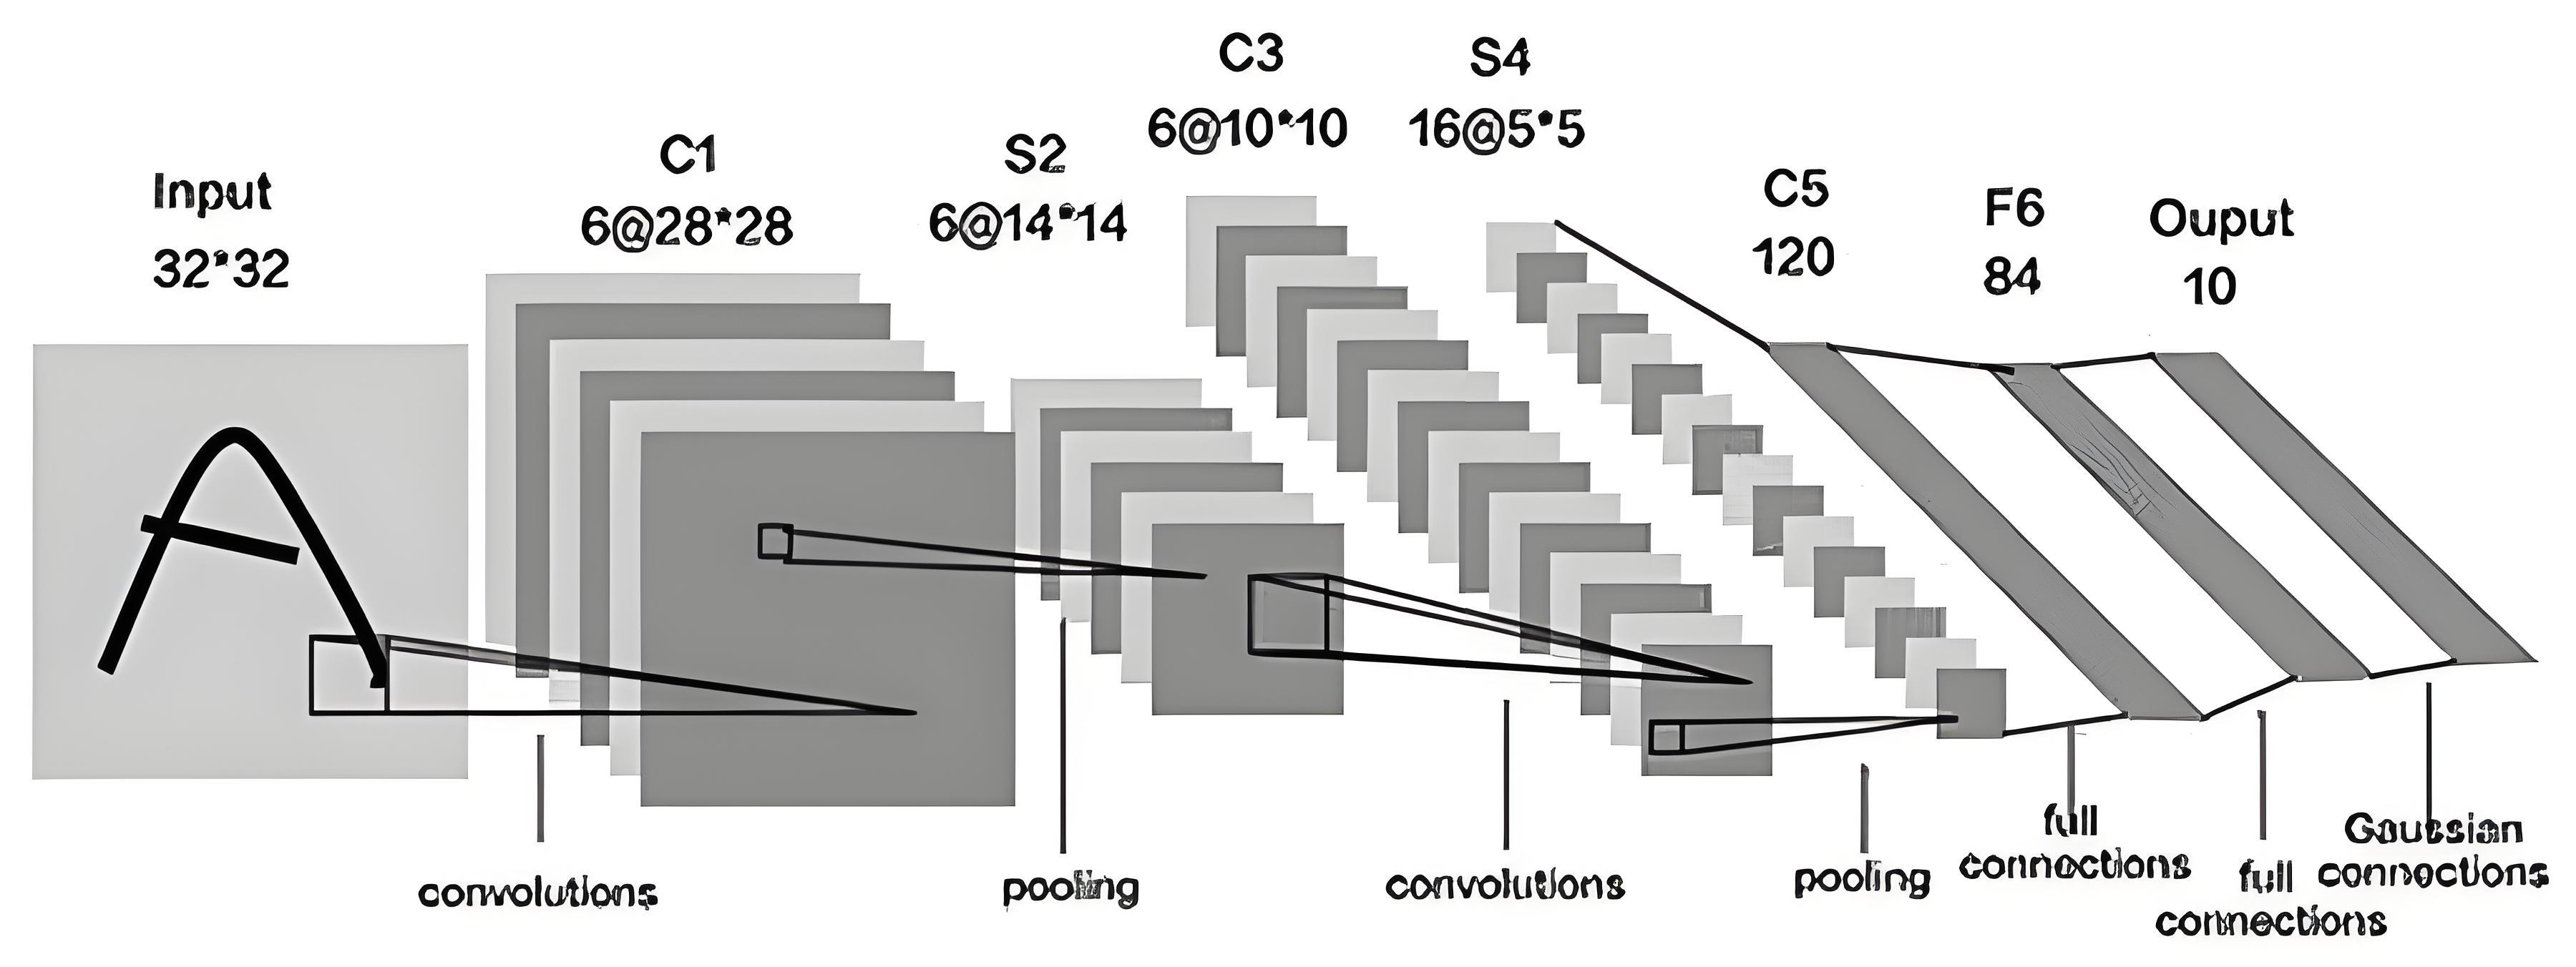

### (1) LeNet-5的使用

- (a) LeNet-5神经网络实现(来自pytorch源代码)

In [1]:
import torch
class LeNet5(torch.nn.Module):
    def __init__(self, cls_num=10):
        super(LeNet5, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 6, 5, padding=2)
        self.relu1 = torch.nn.ReLU(inplace=True)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = torch.nn.Conv2d(6, 16, 5)
        self.relu2 = torch.nn.ReLU(inplace=True)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc3   = torch.nn.Linear(16 * 5 * 5,  120)
        self.relu3 = torch.nn.ReLU(inplace=True)
        
        self.fc4   = torch.nn.Linear(120, 84)
        self.relu4 = torch.nn.ReLU(inplace=True)
        
        self.fc5   = torch.nn.Linear(84, cls_num)

    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        
        x = self.fc3(x)
        x = self.relu3(x)
        
        x = self.fc4(x)
        x = self.relu4(x)

        x = self.fc5(x)
        return x


In [2]:
model_fp32 = LeNet5()
model_fp32

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc3): Linear(in_features=400, out_features=120, bias=True)
  (relu3): ReLU(inplace=True)
  (fc4): Linear(in_features=120, out_features=84, bias=True)
  (relu4): ReLU(inplace=True)
  (fc5): Linear(in_features=84, out_features=10, bias=True)
)

- (b) 加载MINST数据集

In [3]:
import torchvision
from torch.utils.data import DataLoader, Subset

def get_minst_laoder(root="./data", batch_size=128, num_calibration_batches=10):
    """
        num_calibration_batches用于校准的数据集批数。
    """
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ])
    train_dataset = torchvision.datasets.MNIST(root=root, train=True,  download=True, transform=transform)
    test_dataset  = torchvision.datasets.MNIST(root=root, train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader =  torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    # 校准数据集
    indices = torch.randperm(len(train_dataset))[:num_calibration_batches * batch_size]
    calibration_dataset = torch.utils.data.Subset(train_dataset, indices)
    calibration_loader = torch.utils.data.DataLoader(calibration_dataset, batch_size=batch_size, shuffle=False) 
    return train_loader, test_loader, calibration_loader

In [4]:
train_loader, test_loader, calibration_loader = get_minst_laoder(batch_size=1000)
print("训练批数：", len(train_loader))
print("验证批数：", len(test_loader))
print("教研批数：", len(calibration_loader))

训练批数： 60
验证批数： 10
教研批数： 10


- (c) 验证模型

In [5]:
def validate_model(model, test_loader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_ = model(x)
            _, pred = y_.max(1)
            total += y.size(0)
            correct += (pred==y).sum().item()
    accuracy = 100. * correct / total
    return accuracy

In [6]:
accu = validate_model(model_fp32, test_loader)
print(F"没有训练的模型准确度：{accu:5.2f}%")

没有训练的模型准确度： 9.74%


- (d) 训练模型

In [7]:
def train_model_minst(model, train_loader, test_loader, epochs=10):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
    
    train_losses = []
    test_accs = []

    model.to(device)
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_ = model(x)
            loss = criterion(y_, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, pred = y_.max(1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            
            if batch_idx % 30 == 29:
                avg_loss = running_loss / 100
                accuracy = 100. * correct / total
                print(f'轮数: {epoch+1}, 批数: {batch_idx+1}, '
                      f'损失: {avg_loss:7.4f}, 精度: {accuracy:5.2f}%')
        
        # 调整学习率
        scheduler.step()
        # 验证
        test_acc = validate_model(model, test_loader)
        print(F"\t|- 验证精度：{test_acc:5.2f}%")
        test_accs.append(test_acc)
        train_losses.append(running_loss)
        
    return train_losses, test_accs

In [8]:
losses, accs = train_model_minst(model_fp32, train_loader, test_loader, epochs=10)

轮数: 1, 批数: 30, 损失:  0.5608, 精度: 46.61%
轮数: 1, 批数: 60, 损失:  0.7502, 精度: 63.79%
	|- 验证精度：86.97%
轮数: 2, 批数: 30, 损失:  0.1191, 精度: 88.17%
轮数: 2, 批数: 60, 损失:  0.2103, 精度: 89.66%
	|- 验证精度：92.39%
轮数: 3, 批数: 30, 损失:  0.0802, 精度: 91.92%
轮数: 3, 批数: 60, 损失:  0.1577, 精度: 92.24%
	|- 验证精度：92.89%
轮数: 4, 批数: 30, 损失:  0.0773, 精度: 92.44%
轮数: 4, 批数: 60, 损失:  0.1506, 精度: 92.58%
	|- 验证精度：93.06%
轮数: 5, 批数: 30, 损失:  0.0737, 精度: 92.73%
轮数: 5, 批数: 60, 损失:  0.1467, 精度: 92.79%
	|- 验证精度：93.20%
轮数: 6, 批数: 30, 损失:  0.0742, 精度: 92.78%
轮数: 6, 批数: 60, 损失:  0.1459, 精度: 92.80%
	|- 验证精度：93.18%
轮数: 7, 批数: 30, 损失:  0.0737, 精度: 92.91%
轮数: 7, 批数: 60, 损失:  0.1454, 精度: 92.84%
	|- 验证精度：93.19%
轮数: 8, 批数: 30, 损失:  0.0724, 精度: 92.75%
轮数: 8, 批数: 60, 损失:  0.1454, 精度: 92.83%
	|- 验证精度：93.25%
轮数: 9, 批数: 30, 损失:  0.0718, 精度: 92.89%
轮数: 9, 批数: 60, 损失:  0.1453, 精度: 92.84%
	|- 验证精度：93.25%
轮数: 10, 批数: 30, 损失:  0.0735, 精度: 92.67%
轮数: 10, 批数: 60, 损失:  0.1453, 精度: 92.84%
	|- 验证精度：93.25%


- (e) 可视化训练过程数据

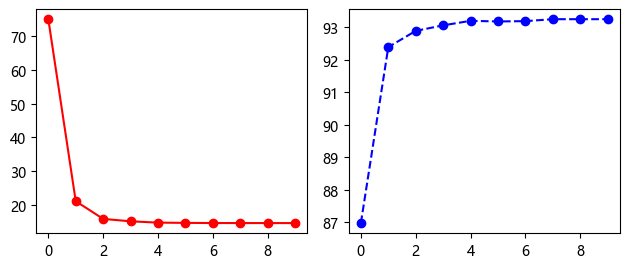

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

fig, axes= plt.subplots(1, 2, figsize=(6.4, 2.8))
axes[0].plot(losses, "o-r")

axes[1].plot(accs, "o--b")
fig.tight_layout()
plt.show()

### (2) LeNet-5的训练感知量化应用

- (a) 训练感知量化版LeNet-5神经网络模型实现

In [1]:
import torch
class QuantLeNet5(torch.nn.Module):
    def __init__(self, cls_num=10):
        super(QuantLeNet5, self).__init__()
        self.quant = torch.ao.quantization.QuantStub()
        self.conv1 = torch.nn.Conv2d(1, 6, 5, padding=2)
        self.relu1 = torch.nn.ReLU(inplace=True)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = torch.nn.Conv2d(6, 16, 5)
        self.relu2 = torch.nn.ReLU(inplace=True)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = torch.nn.Flatten(1)
        
        self.fc3   = torch.nn.Linear(16 * 5 * 5,  120)
        self.relu3 = torch.nn.ReLU(inplace=True)
        
        self.fc4   = torch.nn.Linear(120, 84)
        self.relu4 = torch.nn.ReLU(inplace=True)
        
        self.fc5   = torch.nn.Linear(84, cls_num)
        self.dequant = torch.ao.quantization.DeQuantStub()

    
    def forward(self, x):
        x = self.quant(x)
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        
        x = self.fc3(x)
        x = self.relu3(x)
        
        x = self.fc4(x)
        x = self.relu4(x)

        x = self.fc5(x)
        
        x = self.dequant(x)
        return x

In [2]:
model_fp32 = QuantLeNet5()
model_fp32

QuantLeNet5(
  (quant): QuantStub()
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc3): Linear(in_features=400, out_features=120, bias=True)
  (relu3): ReLU(inplace=True)
  (fc4): Linear(in_features=120, out_features=84, bias=True)
  (relu4): ReLU(inplace=True)
  (fc5): Linear(in_features=84, out_features=10, bias=True)
  (dequant): DeQuantStub()
)

- (b) 训练数据集准备

In [3]:
import torchvision
from torch.utils.data import DataLoader, Subset

def get_minst_laoder(root="./data", batch_size=128, num_calibration_batches=10):
    """
        num_calibration_batches用于校准的数据集批数。
    """
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
    ])
    train_dataset = torchvision.datasets.MNIST(root=root, train=True,  download=True, transform=transform)
    test_dataset  = torchvision.datasets.MNIST(root=root, train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader =  torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    # 校准数据集
    indices = torch.randperm(len(train_dataset))[:num_calibration_batches * batch_size]
    calibration_dataset = torch.utils.data.Subset(train_dataset, indices)
    calibration_loader = torch.utils.data.DataLoader(calibration_dataset, batch_size=batch_size, shuffle=False) 
    return train_loader, test_loader, calibration_loader

In [4]:
train_loader, test_loader, calibration_loader = get_minst_laoder(batch_size=1000)
print("训练批数：", len(train_loader))
print("验证批数：", len(test_loader))
print("教研批数：", len(calibration_loader))

训练批数： 60
验证批数： 10
教研批数： 10


- (c) 模型验证

In [5]:
def validate_model(model, test_loader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_ = model(x)
            _, pred = y_.max(1)
            total += y.size(0)
            correct += (pred==y).sum().item()
    accuracy = 100. * correct / total
    return accuracy

In [6]:
accu = validate_model(model_fp32, test_loader)
print(F"没有训练的模型准确度：{accu:5.2f}%")

没有训练的模型准确度：10.28%


- (d) 量化感知训练

In [7]:
import warnings
warnings.filterwarnings("ignore")

def train_model_minst(model, train_loader, test_loader, epochs=10):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    # ----------------------------------------------------------
    model.to(device)
    
    model.eval()
    model.qconfig = torch.ao.quantization.get_default_qat_qconfig('fbgemm')
    model = torch.ao.quantization.fuse_modules(
        model, 
        [
            ['conv1', 'relu1'],
            ['conv2', 'relu2'],
            ['fc3', 'relu3'],
            ['fc4', 'relu4'],
        ]
    )
    model.train()
    model = torch.ao.quantization.prepare_qat(model)
    # ----------------------------------------------------------
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
    
    train_losses = []
    test_accs = []
    
    for epoch in range(epochs):
        model.train()
        # 训练阶段
        running_loss = 0.0
        correct = 0
        total = 0
        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_ = model(x)
            loss = criterion(y_, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, pred = y_.max(1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            
            if batch_idx % 30 == 29:
                avg_loss = running_loss / 100
                accuracy = 100. * correct / total
                print(f'轮数: {epoch+1}, 批数: {batch_idx+1}, '
                      f'损失: {avg_loss:7.4f}, 精度: {accuracy:5.2f}%')
        
        # 调整学习率
        scheduler.step()
        # 验证
        test_acc = validate_model(model, test_loader)
        print(F"\t|- 验证精度：{test_acc:5.2f}%")
        test_accs.append(test_acc)
        train_losses.append(running_loss)
        
    return model, train_losses, test_accs

In [8]:
model_fp32, losses, accs = train_model_minst(model_fp32, train_loader, test_loader, epochs=10)
print(model_fp32)
# import matplotlib.pyplot as plt
# plt.rcParams["font.family"] = ["Microsoft YaHei"]

# fig, axes= plt.subplots(1, 2, figsize=(6.4, 2.8))
# axes[0].plot(losses, "o-r")

# axes[1].plot(accs, "o--b")
# fig.tight_layout()
# plt.show()

轮数: 1, 批数: 30, 损失:  0.6582, 精度: 57.42%
轮数: 1, 批数: 60, 损失:  1.2574, 精度: 71.61%
	|- 验证精度：89.20%
轮数: 2, 批数: 30, 损失:  0.4748, 精度: 90.73%
轮数: 2, 批数: 60, 损失:  0.7796, 精度: 91.61%
	|- 验证精度：93.76%
轮数: 3, 批数: 30, 损失:  0.1116, 精度: 93.64%
轮数: 3, 批数: 60, 损失:  0.1849, 精度: 93.62%
	|- 验证精度：93.92%
轮数: 4, 批数: 30, 损失:  0.0660, 精度: 93.71%
轮数: 4, 批数: 60, 损失:  0.1264, 精度: 93.86%
	|- 验证精度：94.42%
轮数: 5, 批数: 30, 损失:  0.0584, 精度: 94.27%
轮数: 5, 批数: 60, 损失:  0.1179, 精度: 94.15%
	|- 验证精度：94.47%
轮数: 6, 批数: 30, 损失:  0.0593, 精度: 94.14%
轮数: 6, 批数: 60, 损失:  0.1163, 精度: 94.21%
	|- 验证精度：94.55%
轮数: 7, 批数: 30, 损失:  0.0574, 精度: 94.29%
轮数: 7, 批数: 60, 损失:  0.1156, 精度: 94.25%
	|- 验证精度：94.58%
轮数: 8, 批数: 30, 损失:  0.0563, 精度: 94.34%
轮数: 8, 批数: 60, 损失:  0.1154, 精度: 94.22%
	|- 验证精度：94.55%
轮数: 9, 批数: 30, 损失:  0.0570, 精度: 94.39%
轮数: 9, 批数: 60, 损失:  0.1153, 精度: 94.25%
	|- 验证精度：94.58%
轮数: 10, 批数: 30, 损失:  0.0587, 精度: 94.09%
轮数: 10, 批数: 60, 损失:  0.1153, 精度: 94.24%
	|- 验证精度：94.61%
QuantLeNet5(
  (quant): QuantStub(
    (activation_post_pr

- (e) 验证量化感知训练后的模型

In [9]:
model_fp32.eval()
accu = validate_model(model_fp32, test_loader)
print(F"没有训练的模型准确度：{accu:5.2f}%")

没有训练的模型准确度：94.61%


- (e) 对训练模型进行量化

In [10]:
model_fp32.to("cpu")
model_fp32.eval()
model_int8 = torch.ao.quantization.convert(model_fp32)

- (f) 验证量化后的模型

In [11]:
def validate_model_int8(model, test_loader):
    device = "cpu"
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_ = model(x)
            _, pred = y_.max(1)
            total += y.size(0)
            correct += (pred==y).sum().item()
    accuracy = 100. * correct / total
    return accuracy
    
accu = validate_model_int8(model_int8, test_loader)
print(F"没有训练的模型准确度：{accu:5.2f}%")

没有训练的模型准确度：94.62%


----

## 4.3. 训练感知量化的性能分析

### (1) 量化感知训练

### (2) 模型推理性能比较 

-----